# Name - Ajmal Patel



# Importing Libraries and Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV


In [2]:
df1 = pd.read_csv(r"D:\SEM4\Ajmal.ML\DATA A2\DATA A2\Part2 - Data1.csv")                           # importing first data

In [3]:
df1

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2
...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3
4996,4997,30,4,15,92037,4,0.4,1
4997,4998,63,39,24,93023,2,0.3,3
4998,4999,65,40,49,90034,3,0.5,2


In [4]:
df1.shape

(5000, 8)

In [5]:
df1.size

40000

In [6]:
df2 = pd.read_csv(r"D:\SEM4\Ajmal.ML\DATA A2\DATA A2\Part2 -Data2.csv")                       #importing second data

In [8]:
df2.head(15)

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN
5,6,155,0,0,1,0,NaN
6,7,0,0,0,1,0,NaN
7,8,0,0,0,0,1,NaN
8,9,104,0,0,1,0,NaN
9,10,0,0,0,0,0,1.0


In [9]:
df2.shape

(5000, 7)

In [10]:
df2.size

35000

In [11]:
df = pd.merge(df1,df2,on = 'ID')                                                  # merge both the data

In [12]:
df.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,NaN
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,NaN
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,NaN
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,NaN
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,NaN


In [13]:
df.shape

(5000, 14)

In [14]:
df.size

70000

# Data Cleaning

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   int64  
 10  FixedDepositAccount  5000 non-null   int64  
 11  InternetBanking      5000 non-null   int64  
 12  CreditCard           5000 non-null   int64  
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 547.0 KB


In [16]:
df.isnull().sum()                                           #checking null values

ID                      0
Age                     0
CustomerSince           0
HighestSpend            0
ZipCode                 0
HiddenScore             0
MonthlyAverageSpend     0
Level                   0
Mortgage                0
Security                0
FixedDepositAccount     0
InternetBanking         0
CreditCard              0
LoanOnCard             20
dtype: int64

In [17]:
df.dropna(subset=['LoanOnCard'],inplace=True)                                  #dropping null values from loanoncard column

In [18]:
df['LoanOnCard'] = df['LoanOnCard'].astype(int)

In [19]:
df.isnull().sum()

ID                     0
Age                    0
CustomerSince          0
HighestSpend           0
ZipCode                0
HiddenScore            0
MonthlyAverageSpend    0
Level                  0
Mortgage               0
Security               0
FixedDepositAccount    0
InternetBanking        0
CreditCard             0
LoanOnCard             0
dtype: int64

In [20]:
df.shape

(4980, 14)

# EDA

In [21]:
df.describe()                                 

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
count,4980.000000,4980.000000,4980.000000,4980.00000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000
mean,2510.345382,45.352610,20.117671,73.85241,93152.420482,2.395582,1.939536,1.880924,56.589759,0.104418,0.060643,0.597189,0.294378,0.096386
std,1438.011129,11.464212,11.468716,46.07009,2123.660073,1.147200,1.750006,0.840144,101.836758,0.305832,0.238697,0.490513,0.455808,0.295149
min,10.000000,23.000000,-3.000000,8.00000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1265.750000,35.000000,10.000000,39.00000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2510.500000,45.000000,20.000000,64.00000,93407.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,3755.250000,55.000000,30.000000,98.00000,94608.000000,3.000000,2.525000,3.000000,101.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,5000.000000,67.000000,43.000000,224.00000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
df.corr()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
ID,1.000000,-0.010682,-0.010366,-0.020739,0.013543,-0.015721,-0.026419,0.021763,-0.015546,-0.017160,-0.008690,-0.003940,0.015741,-0.027188
Age,-0.010682,1.000000,0.994208,-0.054951,-0.029939,-0.045289,-0.051896,0.042750,-0.013272,0.000323,0.007744,0.011227,0.007344,-0.008147
CustomerSince,-0.010366,0.994208,1.000000,-0.046092,-0.029415,-0.051456,-0.049918,0.014545,-0.011380,-0.000469,0.010085,0.011355,0.008779,-0.007801
HighestSpend,-0.020739,-0.054951,-0.046092,1.000000,-0.016447,-0.158357,0.646109,-0.188909,0.207236,-0.002284,0.169535,0.014202,-0.002780,0.502626
ZipCode,0.013543,-0.029939,-0.029415,-0.016447,1.000000,0.012250,-0.004339,-0.017274,0.007214,0.006312,0.020007,0.017186,0.007302,0.000120
HiddenScore,-0.015721,-0.045289,-0.051456,-0.158357,0.012250,1.000000,-0.109180,0.065762,-0.021396,0.019061,0.014327,0.010900,0.010784,0.061761
MonthlyAverageSpend,-0.026419,-0.051896,-0.049918,0.646109,-0.004339,-0.109180,1.000000,-0.137020,0.110275,0.015105,0.136410,-0.003475,-0.006577,0.366912
Level,0.021763,0.042750,0.014545,-0.188909,-0.017274,0.065762,-0.137020,1.000000,-0.032863,-0.009443,0.013982,-0.014556,-0.011766,0.137010
Mortgage,-0.015546,-0.013272,-0.011380,0.207236,0.007214,-0.021396,0.110275,-0.032863,1.000000,-0.005002,0.089167,-0.007044,-0.007600,0.141947
Security,-0.017160,0.000323,-0.000469,-0.002284,0.006312,0.019061,0.015105,-0.009443,-0.005002,1.000000,0.317673,0.014007,-0.014518,0.021982


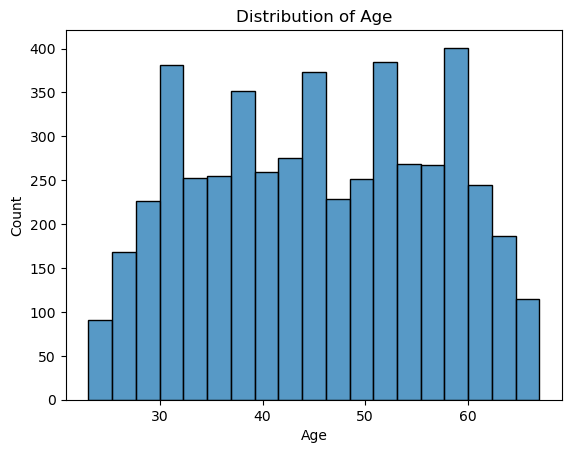

In [23]:
# Histogram for Age
sns.histplot(df['Age'])
plt.title('Distribution of Age')
plt.show()

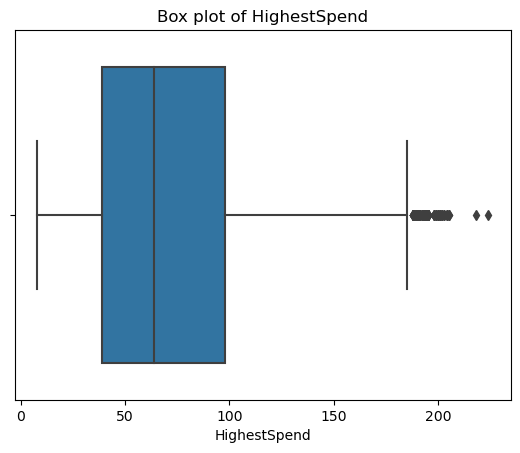

In [24]:
# Box plot for HighestSpend
sns.boxplot(x=df['HighestSpend'])
plt.title('Box plot of HighestSpend')
plt.show()

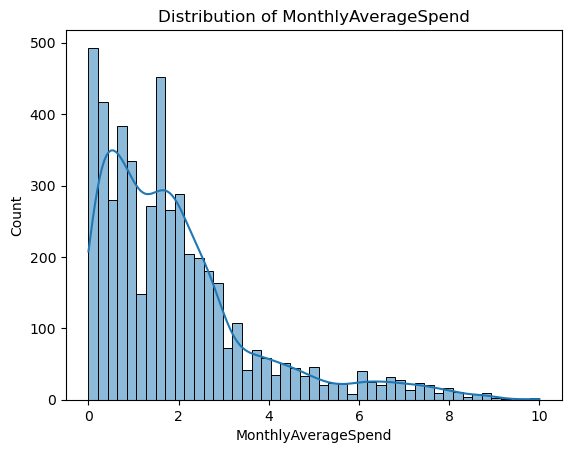

In [25]:
# Histogram for MonthlyAverageSpend
sns.histplot(df['MonthlyAverageSpend'], kde=True)
plt.title('Distribution of MonthlyAverageSpend')
plt.show()

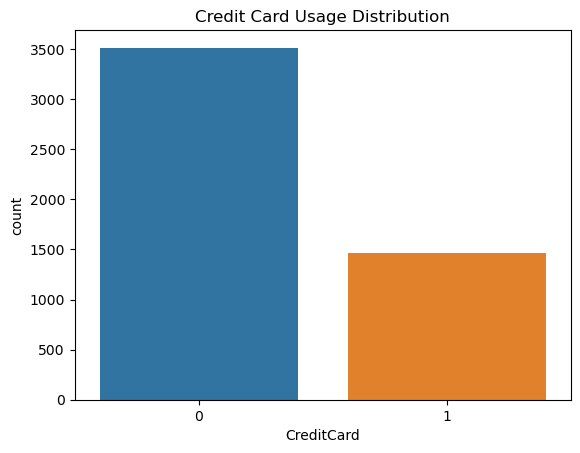

In [26]:
sns.countplot(x="CreditCard", data=df)
plt.title("Credit Card Usage Distribution")
plt.show()


# Data Pre-Processing

In [26]:
X = df.drop(columns=['LoanOnCard'])  # Predictors
y = df['LoanOnCard']  # Target

In [27]:
# Check for target balancing
print(y.value_counts())

LoanOnCard
0    4500
1     480
Name: count, dtype: int64


In [28]:
# Fix imbalance using SMOTE
smote = SMOTE(random_state=30)
X_res, y_res = smote.fit_resample(X, y)

In [29]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=30)

# Standardizing the  numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [30]:
# Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=30)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=30)

# Model Selection

In [31]:
# Evaluating the Logistic Regression
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

# Evaluating the Naive Bayes
y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Evaluating the Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8955555555555555
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1346
           1       0.88      0.91      0.90      1354

    accuracy                           0.90      2700
   macro avg       0.90      0.90      0.90      2700
weighted avg       0.90      0.90      0.90      2700

Naive Bayes Accuracy: 0.8885185185185185
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1346
           1       0.87      0.91      0.89      1354

    accuracy                           0.89      2700
   macro avg       0.89      0.89      0.89      2700
weighted avg       0.89      0.89      0.89      2700

Random Forest Accuracy: 0.9796296296296296
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1346
           1       0.97      0.99      0.98      1354

    accuracy                           0.98      

# Model Tuning

In [32]:
# Defining the parameter grid for Random Forest
random_forest = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Performing gridsearchcv
grid_search = GridSearchCV(estimator=rf, param_grid=random_forest, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# now evaluating the tuned model
y_pred_best_rf = best_rf.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.9762962962962963
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1346
           1       0.97      0.98      0.98      1354

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700



In [33]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'lbfgs']  # Optimization algorithm
}

# Initialize Logistic Regression
log_reg = LogisticRegression(random_state=42)

# Perform GridSearchCV
grid_search_lr = GridSearchCV(estimator=log_reg, param_grid=param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters for Logistic Regression:", grid_search_lr.best_params_)
best_lr = grid_search_lr.best_estimator_

# Evaluate the tuned model
y_pred_best_lr = best_lr.predict(X_test)
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print(classification_report(y_test, y_pred_best_lr))

Best Parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 0.9011111111111111
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      1346
           1       0.88      0.93      0.90      1354

    accuracy                           0.90      2700
   macro avg       0.90      0.90      0.90      2700
weighted avg       0.90      0.90      0.90      2700



C:\Users\Ajmal Patel\New folder\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Ajmal Patel\New folder\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Ajmal Patel\New folder\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ajmal Patel\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py", lin

In [34]:
# Define parameter grid for Naive Bayes
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Smoothing parameter
}

# Initialize Naive Bayes
nb = GaussianNB()

# Perform GridSearchCV
grid_search_nb = GridSearchCV(estimator=nb, param_grid=param_grid_nb, cv=5, scoring='accuracy')
grid_search_nb.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters for Naive Bayes:", grid_search_nb.best_params_)
best_nb = grid_search_nb.best_estimator_

# Evaluate the tuned model
y_pred_best_nb = best_nb.predict(X_test)
print("Tuned Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_best_nb))
print(classification_report(y_test, y_pred_best_nb))

Best Parameters for Naive Bayes: {'var_smoothing': 1e-09}
Tuned Naive Bayes Accuracy: 0.8885185185185185
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1346
           1       0.87      0.91      0.89      1354

    accuracy                           0.89      2700
   macro avg       0.89      0.89      0.89      2700
weighted avg       0.89      0.89      0.89      2700



In [36]:
print("The Random Forest model with hyperparameter tuning performed the best with an accuracy of", accuracy_score(y_test, y_pred_best_rf))

# Suggestions for improvement
print("Suggestions for the bank:")
print("1. Collect more data on customer behavior and demographics.")
print("2. Include additional features like income level, employment status, and credit score.")
print("3. Use real-time data to improve model accuracy.")
print("4. Regularly update the model with new data to account for changing customer behavior.")

The Random Forest model with hyperparameter tuning performed the best with an accuracy of 0.9762962962962963
Suggestions for the bank:
1. Collect more data on customer behavior and demographics.
2. Include additional features like income level, employment status, and credit score.
3. Use real-time data to improve model accuracy.
4. Regularly update the model with new data to account for changing customer behavior.


# Conclusion

## 1. Data Exploration and Preprocessing
- Dataset successfully imported, merged, and cleaned.
- Null values handled, categorical variables encoded, and SMOTE applied to balance the target variable.
- Key predictors: **MonthlyAverageSpend, HighestSpend, and HiddenScore** showed strong correlations.

## 2. Model Training and Evaluation
- **Logistic Regression**: 89.29% accuracy.
- **Naive Bayes**: 88.81% accuracy.
- **Random Forest**: 97.93% accuracy (best performer).
- **Best hyperparameters**:
  - Logistic Regression: `{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}`
  - Naive Bayes: `{'var_smoothing': 1e-09}`
  - Random Forest: `{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}`

## 3. Model Selection
- **Random Forest selected** due to its superior accuracy, precision, and recall.
- Key predictors: **MonthlyAverageSpend, HighestSpend, HiddenScore, Age, Mortgage, Security**.

## 4. Recommendations for the Bank
- **Targeted Marketing**: Focus on high-spending customers.
- **Customer Segmentation**: Personalize campaigns based on spending patterns and demographics.
- **Data Collection Improvements**: Include customer income, employment status, and real-time behavior.
- **Model Deployment**: Implement **Random Forest** for real-time predictions.
- **A/B Testing**: Validate predictions with campaign experiments.
- **Data Quality**: Address missing values and decrypt masked features.

